# Global Stock Market Prediction (2000-2026)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('Global_Stock_Market_Indices_2000_2026.csv', low_memory=False)

print("Dataset Shape:", df.shape)
display(df.head())
display(df.dtypes)


Dataset Shape: (91648, 8)


,Date,Open,High,Low,Close,Volume,Ticker,Index_Name
0,2000-01-03,1469.250000,1478.000000,1438.359985,1455.219971,931800000,^GSPC,S&P 500 (USA)
1,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1009000000,^GSPC,S&P 500 (USA)
2,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1085500000,^GSPC,S&P 500 (USA)
3,2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1092300000,^GSPC,S&P 500 (USA)
4,2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1225200000,^GSPC,S&P 500 (USA)


,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Ticker,object
Index_Name,object


Data Preprocessing

In [3]:
# detecting a suitable closing-price column

close_candidates=[c for c in df.columns if 'close' in c.lower()]
print(close_candidates)

if len(close_candidates)==0:
    raise ValueError("No column containing 'Close' was found.")

close_col=close_candidates[0]
print("Using:", close_col)

df[close_col]=(df[close_col]
               .astype(str)
               .str.replace(',','',regex=False))

df[close_col]=pd.to_numeric(df[close_col],errors='coerce')

df=df.dropna(subset=[close_col]).copy()
print(df.shape)


['Close']
Using: Close
(91648, 8)


Feature Engineering

In [4]:
# Daily percentage return
df['Return'] = df[close_col].pct_change()

# 5 days Moving Average
df['MA5'] = df[close_col].rolling(window=5).mean()

# 5 days Rolling Volatility
df['Volatility'] = df['Return'].rolling(window=5).std()

# Adaptive Momentum (Experimental Feature)
df['AdaptiveMomentum'] = (
    df['Return'] * df['Volatility']
).rolling(window=3).mean()

# Removing rows with missing values
df.dropna(inplace=True)

# Checking newly created features
print(df[['Return','MA5','Volatility','AdaptiveMomentum']].head())

      Return          MA5  Volatility  AdaptiveMomentum
7  -0.004386  1434.665991    0.015451          0.000003
8   0.012170  1443.912012    0.015647         -0.000024
9   0.010671  1448.648022    0.011424          0.000082
10 -0.006832  1448.156030    0.011159          0.000079
11  0.000522  1451.624023    0.008641          0.000017


## Exploratory Data Analysis

,Open,High,Low,Close,Volume,Return,MA5,Volatility,AdaptiveMomentum
count,91641.000000,91641.000000,91641.000000,91641.000000,9.164100e+04,91641.000000,91641.000000,91641.000000,91641.000000
mean,14532.172320,14634.946646,14422.791938,14531.790618,6.993108e+08,0.000259,14531.637597,0.011348,0.000006
std,20442.744117,20603.754770,20284.475835,20448.552521,1.363067e+09,0.018146,20437.646489,0.014292,0.004151
min,466.570007,472.309998,463.540009,468.760010,0.000000e+00,-0.981317,474.372003,0.000366,-0.143940
25%,3449.969971,3473.229980,3421.639893,3450.600098,3.664000e+05,-0.005754,3447.719971,0.005950,-0.000031
50%,7307.189941,7347.100098,7263.600098,7307.899902,1.057000e+08,0.000625,7307.700000,0.009064,0.000004
75%,16634.150391,16750.509766,16518.400391,16642.199219,7.272525e+08,0.006749,16633.579883,0.013713,0.000040
max,191491.000000,192624.000000,190419.000000,191490.000000,9.397454e+10,2.000597,190626.200000,0.905270,0.599112


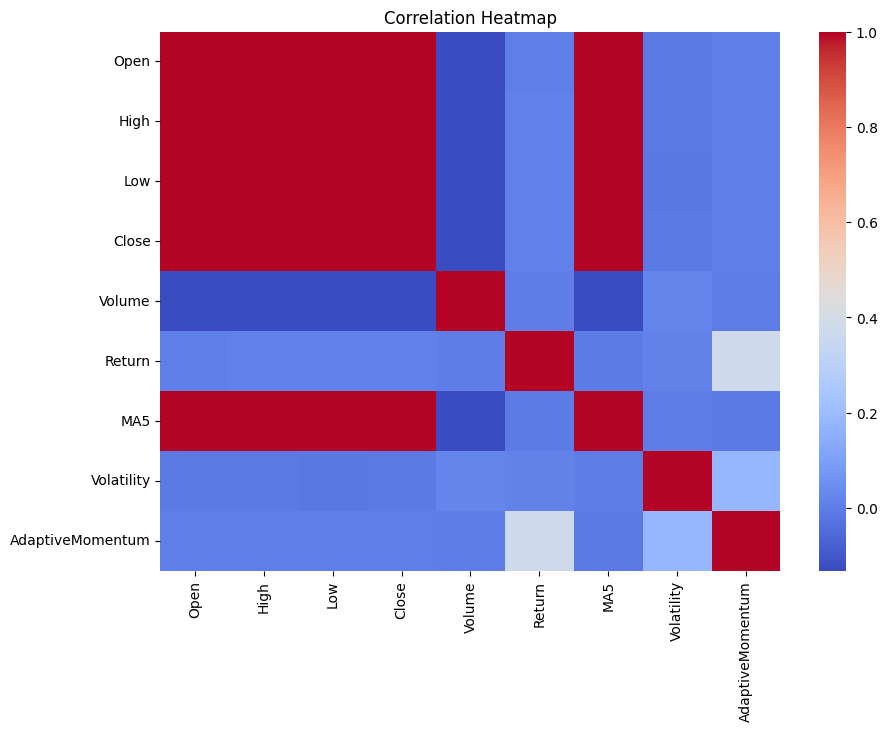

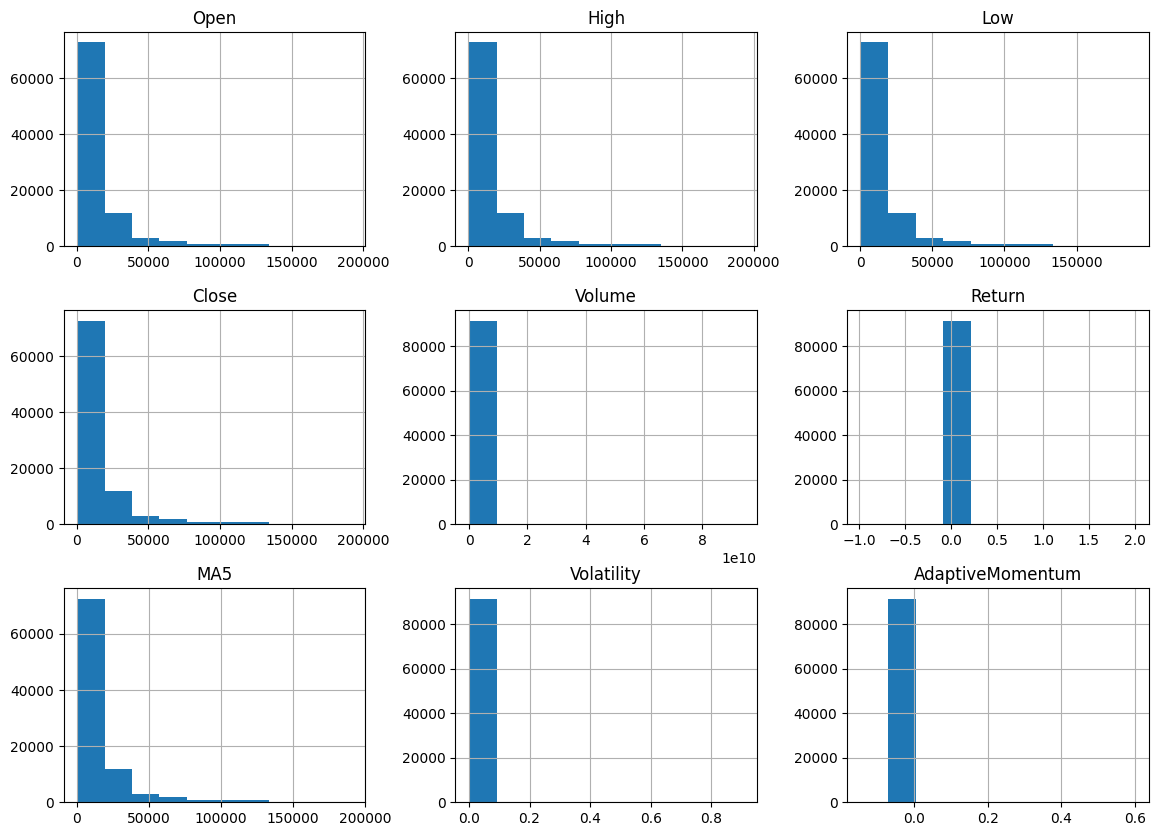

In [4]:
numeric=df.select_dtypes(include=np.number)

display(numeric.describe())

plt.figure(figsize=(10,7))
sns.heatmap(numeric.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

numeric.hist(figsize=(14,10))
plt.show()


Data Preparation

In [5]:
from sklearn.model_selection import TimeSeriesSplit

# Selecting input features
feature_columns = [
    'Return',
    'MA5',
    'Volatility',
    'AdaptiveMomentum'
]

# Features(X) and Target(y)
X = df[feature_columns]
y = df[close_col]

# 80% Training and 20% Testing
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

print("Features:")
print(feature_columns)

print("\nTarget:")
print(close_col)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Features:
['Return', 'MA5', 'Volatility', 'AdaptiveMomentum']

Target:
Close

Training Shape: (73312, 4)
Testing Shape : (18329, 4)


## Random Forest

In [6]:
rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators':[100],
    'max_depth':[10],
    'min_samples_split':[2]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=tscv,
    scoring='neg_mean_squared_error'
)

rf_grid.fit(X_train,y_train)

rf_best = rf_grid.best_estimator_

rf_pred = rf_best.predict(X_test)

## Gradient Boosting

In [7]:
gb = GradientBoostingRegressor(random_state=42)

gb_params = {
    'n_estimators':[100],
    'learning_rate':[0.1],
    'max_depth':[3]
}

gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=tscv,
    scoring='neg_mean_squared_error'
)

gb_grid.fit(X_train,y_train)

gb_best = gb_grid.best_estimator_

gb_pred = gb_best.predict(X_test)

Model Evaluation and Comparison

In [16]:
import pandas as pd

evaluation = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "MAE": [
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ],
    "R² Score": [
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]
})

evaluation

,Model,MAE,RMSE,R² Score
0,Random Forest,3307.998747,11723.060536,0.890738
1,Gradient Boosting,3386.405513,11834.633844,0.888648


Actual and Predicted

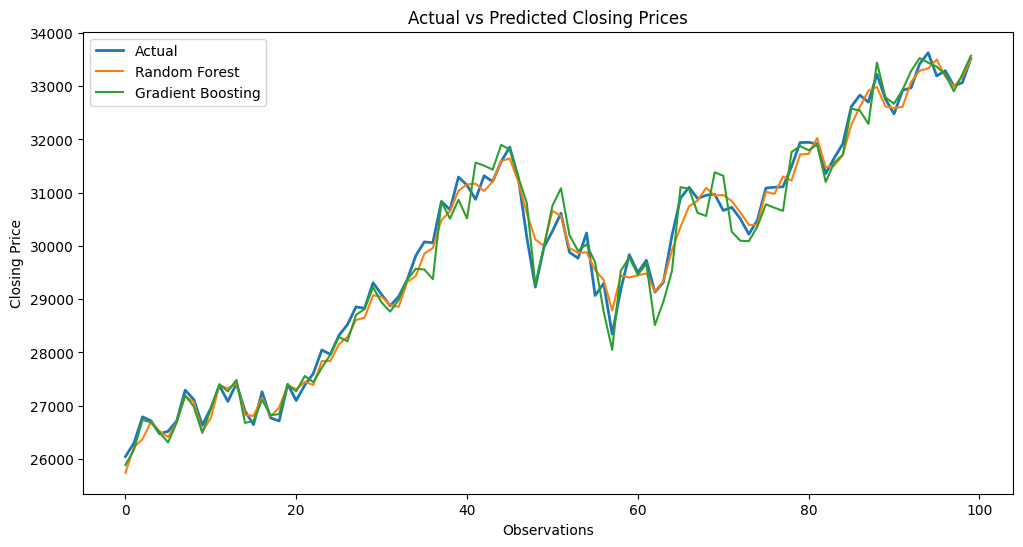

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual", linewidth=2)
plt.plot(rf_pred[:100], label="Random Forest")
plt.plot(gb_pred[:100], label="Gradient Boosting")

plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Observations")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

Feature Importance of Random Forest

            Feature  Importance
1               MA5    0.998679
3  AdaptiveMomentum    0.000725
2        Volatility    0.000408
0            Return    0.000189


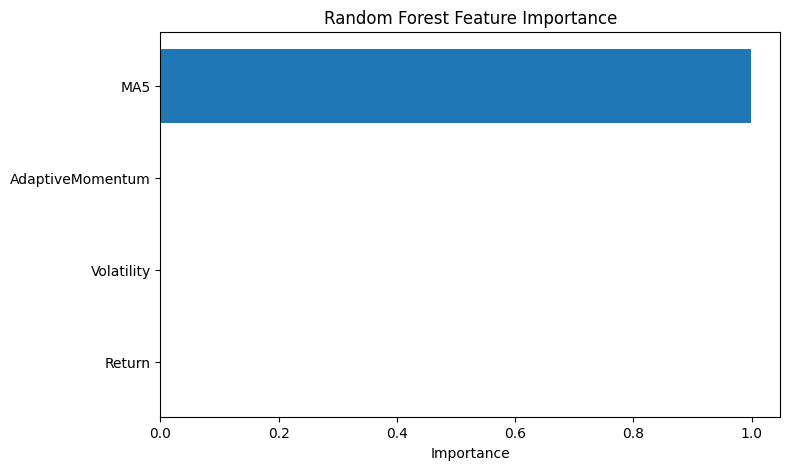

In [18]:
# Feature Importance of Random Forest

import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_best.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance)

plt.figure(figsize=(8,5))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.show()

Feature Importance of Gradient Boosting

            Feature  Importance
1               MA5    0.998681
2        Volatility    0.000647
3  AdaptiveMomentum    0.000631
0            Return    0.000042


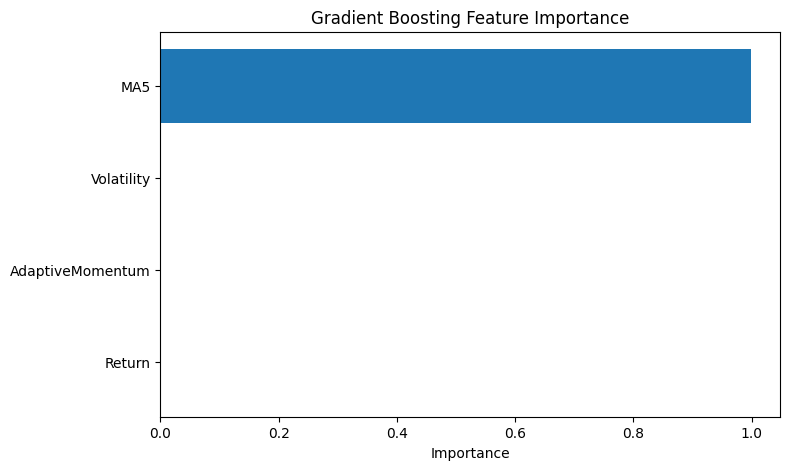

In [19]:
# Feature Importance of Gradient Boosting

gb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_best.feature_importances_
})

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
)

print(gb_importance)

plt.figure(figsize=(8,5))

plt.barh(
    gb_importance["Feature"],
    gb_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")

plt.show()

Model Optimisation

In [20]:
# Hyperparameter Optimisation

print("Random Forest Best Parameters")
print(rf_grid.best_params_)

print("\nGradient Boosting Best Parameters")
print(gb_grid.best_params_)

Random Forest Best Parameters
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

Gradient Boosting Best Parameters
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


Critical Comparison

In [21]:
best_model = evaluation.loc[evaluation["R² Score"].idxmax()]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model       Random Forest
MAE           3307.998747
RMSE         11723.060536
R² Score         0.890738
Name: 0, dtype: object
